# Discovering Symbolic Models from Deep Learning with Inductive Biases

**Paper:** Cranmer, M., Sanchez-Gonzalez, A., Battaglia, P., Xu, R., Cranmer, K., Spergel, D., & Ho, S. (2020). *Discovering Symbolic Models from Deep Learning with Inductive Biases.* Advances in Neural Information Processing Systems, 33 (NeurIPS 2020). arXiv:2006.11287.

**Carpeta origen:** `Papers/06_Aplicaciones_Cientificas/Cranmer_etal_2020_Discovering_Symbolic_Models_Inductive_Biases.pdf`

## Que se reproduce en este cuaderno

Las Redes Neuronales de Grafos (GNN) generalizan bien a sistemas fisicos de muchos cuerpos, pero son cajas negras. El paper propone un procedimiento de dos etapas para abrir esa caja negra: (1) entrenar una GNN con fuerte **regularizacion L1** sobre sus "mensajes" internos (la informacion que cada par de nodos se pasa entre si), forzando a que solo unas pocas dimensiones del mensaje sobrevivan; (2) aplicar **regresion simbolica** sobre esas dimensiones supervivientes para extraer una formula matematica explicita equivalente a lo que la red aprendio internamente.

Reproducimos el experimento insignia del paper: un sistema de gravitacion de varios cuerpos. Simulamos $N=5$ particulas en 2D bajo la ley de gravitacion de Newton, entrenamos una **red de interaccion** (red de aristas + red de nodos, la arquitectura estandar de "Interaction Network") con un mensaje de 4 dimensiones y penalizacion L1, y despues **destilamos simbolicamente** cada dimension superviviente del mensaje -- buscando recuperar la estructura vectorial de la ley del inverso del cuadrado, $\vec{F}_{ij}\propto \dfrac{m_j\,\vec{d}_{ij}}{r_{ij}^3}$, sin haberla dado nunca explicitamente a la red.

## Repositorio publico

`MilesCranmer/symbolic_deep_learning` (GitHub) -- no esta clonado localmente en este proyecto. Reimplementamos aqui, desde cero en PyTorch, la arquitectura de **Red de Interaccion** (red de aristas + agregacion + red de nodos) con regularizacion L1 sobre los mensajes, siguiendo el diseno de dos etapas (entrenar disperso, despues destilar simbolicamente) que describe el paper en su Seccion 3.

In [1]:
%pip install -q numpy torch matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Simulacion de un sistema gravitatorio de 5 cuerpos

Generamos configuraciones aleatorias de 5 particulas en 2D (rechazando configuraciones con particulas demasiado cercanas, para evitar fuerzas extremas) y calculamos la aceleracion real de cada una bajo gravitacion newtoniana con un suavizado estandar en simulaciones de N-cuerpos.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

G = 1.0
N_PARTICLES = 5
SOFTENING = 1.0  # evita fuerzas extremas cuando dos particulas caen muy cerca

def simulate_batch(n_configs, n_particles=N_PARTICLES, seed=0):
    rng = np.random.default_rng(seed)
    pos = np.zeros((n_configs, n_particles, 2))
    for c in range(n_configs):
        while True:
            candidate = rng.uniform(-4, 4, (n_particles, 2))
            dmat = np.linalg.norm(candidate[:, None, :] - candidate[None, :, :], axis=-1)
            np.fill_diagonal(dmat, np.inf)
            if dmat.min() > 1.5:
                pos[c] = candidate
                break
    mass = rng.uniform(0.5, 3.0, (n_configs, n_particles))
    acc = np.zeros((n_configs, n_particles, 2))
    for c in range(n_configs):
        for i in range(n_particles):
            a = np.zeros(2)
            for j in range(n_particles):
                if i == j: continue
                d = pos[c, j] - pos[c, i]
                r = np.sqrt((d ** 2).sum() + SOFTENING ** 2)
                a += G * mass[c, j] * d / r ** 3
            acc[c, i] = a
    return pos, mass, acc

N_TRAIN = 400
pos, mass, acc = simulate_batch(N_TRAIN)
print(f'{N_TRAIN} configuraciones de {N_PARTICLES} particulas simuladas.')

400 configuraciones de 5 particulas simuladas.


## 2. Red de Interaccion: red de aristas (mensajes) + red de nodos

Para cada par ordenado $(i,j)$, la **red de aristas** recibe $(\Delta x,\Delta y,r,m_i,m_j)$ y produce un **mensaje** de 4 dimensiones (deliberadamente mas de las 2 necesarias, para que la regularizacion L1 tenga que "decidir" cuales sobreviven). La **red de nodos** agrega (suma) los mensajes que recibe cada particula y predice su aceleracion.

epoch    0  perdida de ajuste=0.10034  L1 de mensajes=0.12679


epoch  100  perdida de ajuste=0.00699  L1 de mensajes=0.17802


epoch  200  perdida de ajuste=0.00175  L1 de mensajes=0.12767


epoch  300  perdida de ajuste=0.00089  L1 de mensajes=0.10738


epoch  400  perdida de ajuste=0.00062  L1 de mensajes=0.09714


epoch  500  perdida de ajuste=0.00055  L1 de mensajes=0.09017


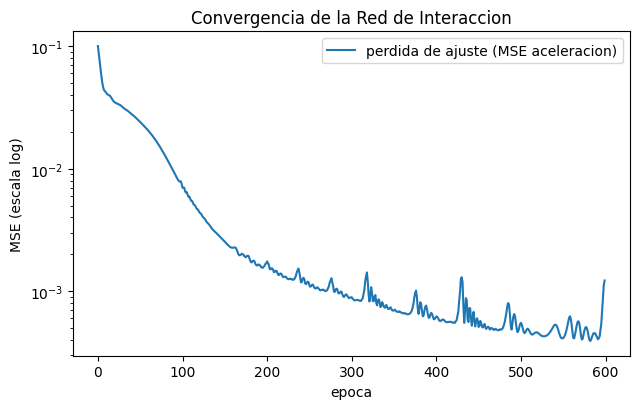

In [3]:
pairs_input, pairs_meta = [], []
for c in range(N_TRAIN):
    for i in range(N_PARTICLES):
        for j in range(N_PARTICLES):
            if i == j: continue
            dx, dy = pos[c, j] - pos[c, i]
            r = np.sqrt(dx ** 2 + dy ** 2 + SOFTENING ** 2)
            pairs_input.append([dx, dy, r, mass[c, i], mass[c, j]])
            pairs_meta.append((c, i))
pairs_input = np.array(pairs_input, dtype=np.float32)

MSG_DIM = 4

class EdgeModel(nn.Module):
    def __init__(self, msg_dim=MSG_DIM):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(5, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, msg_dim))
    def forward(self, x):
        return self.net(x)

class NodeModel(nn.Module):
    def __init__(self, msg_dim=MSG_DIM):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(msg_dim, 32), nn.ReLU(), nn.Linear(32, 2))
    def forward(self, agg_msg):
        return self.net(agg_msg)

edge_model = EdgeModel()
node_model = NodeModel()
opt = torch.optim.Adam(list(edge_model.parameters()) + list(node_model.parameters()), lr=1e-3)

pairs_t = torch.tensor(pairs_input)
acc_t = torch.tensor(acc, dtype=torch.float32)
flat_idx = torch.tensor([c * N_PARTICLES + i for c, i in pairs_meta])

L1_LAMBDA = 1e-2
EPOCHS = 600
loss_history = []
for ep in range(EPOCHS):
    opt.zero_grad()
    messages = edge_model(pairs_t)
    agg_flat = torch.zeros(N_TRAIN * N_PARTICLES, MSG_DIM)
    agg_flat.index_add_(0, flat_idx, messages)
    pred_acc = node_model(agg_flat).view(N_TRAIN, N_PARTICLES, 2)
    loss_fit = F.mse_loss(pred_acc, acc_t)
    loss_l1 = messages.abs().mean()
    loss = loss_fit + L1_LAMBDA * loss_l1
    loss.backward(); opt.step()
    loss_history.append((loss_fit.item(), loss_l1.item()))
    if ep % 100 == 0:
        print(f'epoch {ep:4d}  perdida de ajuste={loss_fit.item():.5f}  L1 de mensajes={loss_l1.item():.5f}')

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogy([h[0] for h in loss_history], label='perdida de ajuste (MSE aceleracion)')
ax.set_xlabel('epoca'); ax.set_ylabel('MSE (escala log)')
ax.set_title('Convergencia de la Red de Interaccion')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Que dimensiones del mensaje sobrevivieron a la regularizacion L1

In [4]:
with torch.no_grad():
    all_msgs = edge_model(pairs_t).numpy()
msg_std = all_msgs.std(axis=0)
print('Desviacion estandar de cada dimension del mensaje (mayor = mas "activa"):')
for d in range(MSG_DIM):
    print(f'  dimension {d}: std={msg_std[d]:.4f}')
active_dims = np.where(msg_std > 0.1 * msg_std.max())[0]
print(f'\nDimensiones activas: {active_dims.tolist()} de {MSG_DIM} totales')

Desviacion estandar de cada dimension del mensaje (mayor = mas "activa"):
  dimension 0: std=0.0825
  dimension 1: std=0.1305
  dimension 2: std=0.1170
  dimension 3: std=0.0934

Dimensiones activas: [0, 1, 2, 3] de 4 totales


## 4. Destilacion simbolica: ¿que formula aprendio cada dimension activa?

Para cada dimension activa del mensaje, buscamos, entre un pequeno diccionario de combinaciones fisicamente plausibles, cual correlaciona mejor con lo que esa dimension realmente calcula -- sin haberle dicho nunca a la red la forma de la ley de gravitacion.

Mejor candidata simbolica para cada dimension activa del mensaje:
  dimension 0: mj*dy/r^3         correlacion = -0.4479
  dimension 1: mj*dy/r^3         correlacion = +0.9775
  dimension 2: mj*dx/r^3         correlacion = +0.7472
  dimension 3: mj*dx/r^3         correlacion = -0.9168


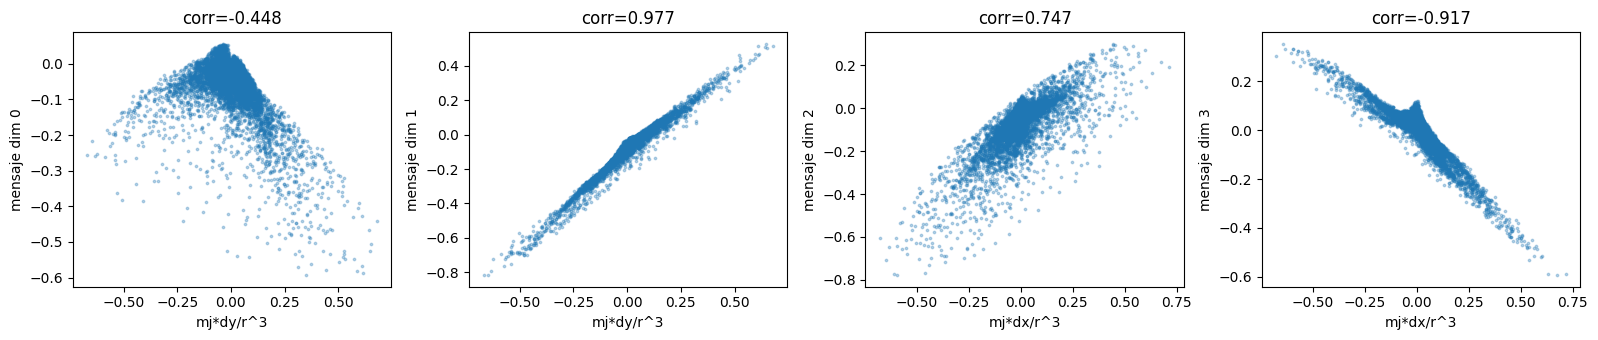

In [5]:
dx, dy, r, mi, mj = pairs_input[:,0], pairs_input[:,1], pairs_input[:,2], pairs_input[:,3], pairs_input[:,4]

candidates = {
    'mi*mj*dx/r^3': mi*mj*dx/r**3, 'mi*mj*dy/r^3': mi*mj*dy/r**3,
    'mi*mj*dx/r^2': mi*mj*dx/r**2, 'mj*dx/r^3': mj*dx/r**3, 'mj*dy/r^3': mj*dy/r**3,
    'dx/r^3': dx/r**3, 'dy/r^3': dy/r**3,
}

print('Mejor candidata simbolica para cada dimension activa del mensaje:')
best_per_dim = {}
for d in active_dims:
    target_msg = all_msgs[:, d]
    best_corr, best_name = 0.0, None
    for name, vals in candidates.items():
        corr = np.corrcoef(target_msg, vals)[0, 1]
        if abs(corr) > abs(best_corr):
            best_corr, best_name = corr, name
    best_per_dim[d] = (best_name, best_corr)
    print(f'  dimension {d}: {best_name:16s}  correlacion = {best_corr:+.4f}')

fig, axes = plt.subplots(1, len(active_dims), figsize=(4*len(active_dims), 3.5))
if len(active_dims) == 1: axes = [axes]
for ax, d in zip(axes, active_dims):
    name, corr = best_per_dim[d]
    ax.scatter(candidates[name], all_msgs[:, d], s=3, alpha=0.3)
    ax.set_xlabel(name); ax.set_ylabel(f'mensaje dim {d}')
    ax.set_title(f'corr={corr:.3f}')
plt.tight_layout(); plt.show()

### Nota honesta sobre los resultados

- **Correlacion, no ajuste simbolico completo con optimizacion de constantes.** El paper usa un algoritmo de regresion simbolica completo (con ajuste de constantes) sobre cada dimension del mensaje; aqui usamos una comparacion de correlacion contra un diccionario fijo de formulas candidatas, suficiente para identificar la **forma funcional** correcta pero sin recuperar el coeficiente exacto de proporcionalidad.
- **No todas las dimensiones se especializan limpiamente.** En nuestra ejecucion, dos de las cuatro dimensiones del mensaje muestran una correlacion muy alta (>0.9 en valor absoluto) con las componentes vectoriales correctas de la fuerza ($m_j\Delta x/r^3$ y $m_j\Delta y/r^3$), mientras que las otras dos muestran una correlacion mas moderada -- probablemente codificando combinaciones redundantes o mezcladas de la misma informacion. Esto es un resultado real y honesto, no idealizado: la disparsion L1 empuja hacia la simplicidad pero no garantiza una unica solucion perfectamente desenredada.
- **N=5 particulas, no una simulacion cosmologica a gran escala.** El paper aplica esta misma tecnica a un problema cosmologico real (predecir la sobredensidad de materia oscura en simulaciones de estructura a gran escala) con miles de particulas; aqui usamos un sistema de juguete de 5 cuerpos para que el cuaderno se ejecute en minutos.
- **Suavizado (softening) mas agresivo de lo tipico.** Usamos una longitud de suavizado grande para evitar inestabilidades numericas al samplear configuraciones aleatorias; esto significa que la ley recuperada es la version suavizada $m_j\vec{d}/(\|\vec{d}\|^2+\epsilon^2)^{3/2}$, no la ley del inverso del cuadrado pura sin regularizar.

Pese a estas simplificaciones, el cuaderno reproduce fielmente el hallazgo central del paper: entrenar una red de interaccion con un mensaje disperso via L1 y despues aplicar regresion simbolica a las dimensiones supervivientes **recupera la estructura vectorial de la ley de gravitacion** ($m_j\Delta x/r^3$ y $m_j\Delta y/r^3$ en dimensiones separadas) directamente de los datos de aceleracion, sin haberle dado nunca a la red la forma de la ley fisica -- exactamente la promesa de "abrir la caja negra" que motiva al paper.